In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy as sp
import os

#read the excel document and first Visualization, the initial information show us the dimension, structure, with this part, we make sure we dont have Null Values or duplicated

In [9]:
#route

df=pd.read_excel(r"C:\Users\hecto\Documents\Especializacion en Data Science\Modulo 4- Python para Ciencia de datos\Semana I\BD Honduras Market - Mejorar.xlsx",
                sheet_name='Dataset', skiprows=2)

df.head()
print(f"[INFO] Initial dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")


[INFO] Initial dataset loaded with 369 rows and 17 columns.


In [14]:

 #start with the initial information and EDA
print("=" * 60)
print("STARTING EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)
    
# 2. Dataset Dimensions
print("=== 1. DATASET DIMENSIONS ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")
    
# 3. Data Structure and Types
print("=== 2. DATA STRUCTURE & DATA TYPES ===")
print(df.info())
print("\n")
    
# 4. Missing Value Assessment
print("=== 3. MISSING VALUES DETECTED ===")
missing_values = df.isnull().sum()
missing_cols = missing_values[missing_values > 0]
if not missing_cols.empty:
    print(missing_cols)
else:
    print("No missing values detected in the dataset.")
print("\n")
    
# 5. Duplicate Rows Check
print("=== 4. DUPLICATE RECORDS CHECK ===")
duplicate_count = df.duplicated().sum()
print(f"Number of perfectly identical rows: {duplicate_count}\n")
    
 # 6. Descriptive Statistics for Numerical Variables
print("=== 5. DESCRIPTIVE STATISTICS (NUMERICAL) ===")
numerical_summary = df[['Precio unitario', 'Cantidad', 'Ingresos', 'Tarifa de envío']].describe()
print(numerical_summary)
print("\n")
    
# 7. Cardinality of Categorical Features
print("=== 6. CATEGORICAL FEATURES CARDINALITY ===")
categorical_cols = ['Ciudad', 'Departamento', 'Vendedor', 'Region', 'Empresa fletera', 'Forma de pago', 'Categoría']
for col in categorical_cols:
    print(f"Feature '{col}': {df[col].nunique()} unique categories.")
print("\n")
    
  

STARTING EXPLORATORY DATA ANALYSIS (EDA)
=== 1. DATASET DIMENSIONS ===
Total Rows: 369
Total Columns: 17

=== 2. DATA STRUCTURE & DATA TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Folio                369 non-null    int64         
 1   Fecha de orden       369 non-null    datetime64[ns]
 2   Num. cliente         369 non-null    int64         
 3   Nombre cliente       369 non-null    object        
 4   Ciudad               369 non-null    object        
 5   Departamento         369 non-null    object        
 6   Vendedor             369 non-null    object        
 7   Region               369 non-null    object        
 8   Fecha de embarque    291 non-null    datetime64[ns]
 9   Empresa fletera      330 non-null    object        
 10  Forma de pago        267 non-null    object        
 11  Nomb

In this part, we continue with all the analysis of Outlier vlaues and we write a rule to filtrate the df to outlier values.
we check that we have 3 extreme values, but they were connected with the quantity of products asked for.

In [15]:
    print("=" * 60)
    print("DEVELOPING BOXPLOTS & OUTLIER DETECTION")
    print("=" * 60)
    
    # 2. Define numerical features to analyze
    numerical_features = ['Precio unitario', 'Cantidad', 'Ingresos', 'Tarifa de envío']
    
    # Set professional style for data visualization
    sns.set_theme(style="whitegrid")
    
    # 3. Generate individual boxplots and calculate IQR Outliers
    for feature in numerical_features:
        print(f"\n>>> Analyzing Feature: '{feature}' <<<")
        
        # --- Visualizing Outliers ---
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[feature], color="#4C72B0", flierprops={"marker": "x", "markeredgecolor": "red"})
        
        plt.title(f"Boxplot Distribution & Outlier Identification for: {feature}", fontsize=12, pad=15)
        plt.xlabel(feature, fontsize=10)
        plt.tight_layout()
        
        # Save plot locally
        filename = f"boxplot_{feature.lower().replace(' ', '_')}.png"
        plt.savefig(filename, dpi=300)
        plt.close()
        print(f"[SUCCESS] Boxplot saved as '{filename}'")
        
        # --- Mathematical Outlier Detection (IQR Method) ---
        q1 = df[feature].quantile(0.25)
        q3 = df[feature].quantile(0.75)
        iqr = q3 - q1
        
        # Define limits for extreme values
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Filter dataframe to isolate outliers
        outliers_df = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
        
        print(f"Statistical Bounds -> Lower Limit: {lower_bound:.2f} | Upper Limit: {upper_bound:.2f}")
        print(f"Total outliers detected for {feature}: {outliers_df.shape[0]} records.")
        
        # Display the highest extreme values if they exist
        if not outliers_df.empty:
            print("Top 3 extreme values identified:")
            print(outliers_df[['Folio', 'Nombre cliente', feature]].dropna().tail(3).to_string(index=False))
            
    print("\n" + "=" * 60)
    print("OUTLIER DETECTION PIPELINE COMPLETED SUCCESSFULLY")
    print("=" * 60)

DEVELOPING BOXPLOTS & OUTLIER DETECTION

>>> Analyzing Feature: 'Precio unitario' <<<
[SUCCESS] Boxplot saved as 'boxplot_precio_unitario.png'
Statistical Bounds -> Lower Limit: -393.05 | Upper Limit: 1015.35
Total outliers detected for Precio unitario: 9 records.
Top 3 extreme values identified:
 Folio        Nombre cliente  Precio unitario
  1309 Supermercado Sandoval           1134.0
  1350 Supermercado Sandoval           1134.0
  1406 Supermercado Sandoval           1134.0

>>> Analyzing Feature: 'Cantidad' <<<
[SUCCESS] Boxplot saved as 'boxplot_cantidad.png'
Statistical Bounds -> Lower Limit: -36.88 | Upper Limit: 150.12
Total outliers detected for Cantidad: 0 records.

>>> Analyzing Feature: 'Ingresos' <<<
[SUCCESS] Boxplot saved as 'boxplot_ingresos.png'
Statistical Bounds -> Lower Limit: -17587.50 | Upper Limit: 43446.90
Total outliers detected for Ingresos: 32 records.
Top 3 extreme values identified:
 Folio          Nombre cliente  Ingresos
  1374 Supermercado La Entrada   5

# inspectig Unique Values
In this process, we check the string values to check if we dont have duplicated names, or names write it in a different way.

In [16]:

    print("=" * 60)
    print("INSPECTING UNIQUE VALUES AND CATEGORIES")
    print("=" * 60)
    
   
    # List of categorical columns we want to inspect
    target_columns = ['Ciudad', 'Departamento', 'Vendedor', 'Region', 'Empresa fletera', 'Forma de pago']
    
    for col in target_columns:
        print(f"\n>>> FOR COLUMN: '{col}' <<<")
        
        # 1. Get the list of unique elements
        unique_elements = df[col].dropna().unique()
        print(f"Total Unique Elements ({len(unique_elements)}):")
        print(list(unique_elements))
        
        print("-" * 40)
        
        # 2. Get the distribution (how many times each element appears)
        print("Value Counts / Frequency Distribution:")
        print(df[col].value_counts(dropna=False))
        print("=" * 60)

INSPECTING UNIQUE VALUES AND CATEGORIES

>>> FOR COLUMN: 'Ciudad' <<<
Total Unique Elements (8):
['San Pedro Sula', 'Santa Rosa de Copán', 'La Entrada', 'Siguatepeque', 'Tegucigalpa', 'Tela', 'Roatán', 'Santa Barbara']
----------------------------------------
Value Counts / Frequency Distribution:
Ciudad
Tegucigalpa            93
San Pedro Sula         85
Santa Rosa de Copán    63
Roatán                 45
Tela                   36
Santa Barbara          25
Siguatepeque           16
La Entrada              6
Name: count, dtype: int64

>>> FOR COLUMN: 'Departamento' <<<
Total Unique Elements (7):
['Cortés', 'Copán', 'Comayagua', 'Francisco Morazán', 'Atlantida', 'Islas de la Bahia', 'Santa Barbara']
----------------------------------------
Value Counts / Frequency Distribution:
Departamento
Francisco Morazán    93
Cortés               85
Copán                69
Islas de la Bahia    45
Atlantida            36
Santa Barbara        25
Comayagua            16
Name: count, dtype: int64

>>> 

# Advanced Data Cleaning & Imputation

Now, we are gonna clean the dat set, ordering dates, dropping the 3 incomplete rows

In [17]:
    print("=" * 60)
    print("STARTING ADVANCED DATA CLEANING & IMPUTATION")
    print("=" * 60)
    
    # 2. Convert date columns to datetime format safely
    df['Fecha de orden'] = pd.to_datetime(df['Fecha de orden'])
    df['Fecha de embarque'] = pd.to_datetime(df['Fecha de embarque'])
    
    # 3. Handle Critical Financial Nulls (Drop the 3 incomplete product rows)
    # These 3 rows lack core transaction variables and cannot be securely rebuilt
    financial_cols = ['Nombre del producto', 'Precio unitario', 'Cantidad', 'Ingresos']
    df.dropna(subset=financial_cols, inplace=True)
    print(f"[INFO] Dropped 3 records with critical financial missing values. Remaining rows: {df.shape[0]}")
    
    # 4. Handle Categorical Nulls (Imputation with placeholder string)
    df['Forma de pago'] = df['Forma de pago'].fillna('Not Specified')
    df['Empresa fletera'] = df['Empresa fletera'].fillna('Not Specified')
    print("[INFO] Categorical missing values imputed with 'Not Specified'.")
    
    # 5. Smart Imputation for 'Fecha de embarque' using Average Shipping Lead Time
    # Step A: Calculate the historic shipping duration (in days) for non-null records
    completed_orders = df[df['Fecha de embarque'].notnull()].copy()
    shipping_days = (completed_orders['Fecha de embarque'] - completed_orders['Fecha de orden']).dt.days
    
    # Step B: Compute the median shipping days (safer than mean to avoid outlier skewness)
    median_lead_time = int(np.round(shipping_days.median()))
    print(f"[INFO] Calculated historical median shipping lead time: {median_lead_time} days.")
    
    # Step C: Impute missing shipping dates by adding the median lead time to 'Fecha de orden'
    missing_shipping_mask = df['Fecha de embarque'].isnull()
    df.loc[missing_shipping_mask, 'Fecha de embarque'] = df.loc[missing_shipping_mask, 'Fecha de orden'] + pd.to_timedelta(median_lead_time, unit='D')
    print(f"[INFO] Imputed {missing_shipping_mask.sum()} missing shipping dates using historical lead time.")
    
    # 6. Final Validation Verification
    print("-" * 60)
    print("VERIFYING POST-CLEANING HEALTH STATUS:")
    remaining_nulls = df.isnull().sum()
    print(remaining_nulls[remaining_nulls > 0] if remaining_nulls.sum() > 0 else "All missing values successfully resolved (0 nulls remaining).")
    print("=" * 60)
    
    



STARTING ADVANCED DATA CLEANING & IMPUTATION
[INFO] Dropped 3 records with critical financial missing values. Remaining rows: 366
[INFO] Categorical missing values imputed with 'Not Specified'.
[INFO] Calculated historical median shipping lead time: 2 days.
[INFO] Imputed 78 missing shipping dates using historical lead time.
------------------------------------------------------------
VERIFYING POST-CLEANING HEALTH STATUS:
All missing values successfully resolved (0 nulls remaining).


In [18]:
print("--- BASELINE MISSING VALUES ---")
print(df[['Empresa fletera', 'Forma de pago']].isnull().sum())
print("-" * 40)
        
    # 2. Impute missing values with a professional placeholder
df['Empresa fletera'] = df['Empresa fletera'].fillna('Not Specified')
df['Forma de pago'] = df['Forma de pago'].fillna('Not Specified')
        
    # 3. Standardize string formatting
df['Empresa fletera'] = df['Empresa fletera'].astype(str).str.strip()
df['Forma de pago'] = df['Forma de pago'].astype(str).str.strip()
        
    # 4. Verification and Validation Phase
print("--- POST-CLEANING FREQUENCY DISTRIBUTIONS ---")
print("\n[VERIFICATION] 'Empresa fletera' Distribution:")
print(df['Empresa fletera'].value_counts())
print("\n[VERIFICATION] 'Forma de pago' Distribution:")
print(df['Forma de pago'].value_counts())
print("-" * 60)
print("CATEGORICAL DATA CLEANING COMPLETED")
print("=" * 60)







--- BASELINE MISSING VALUES ---
Empresa fletera    0
Forma de pago      0
dtype: int64
----------------------------------------
--- POST-CLEANING FREQUENCY DISTRIBUTIONS ---

[VERIFICATION] 'Empresa fletera' Distribution:
Empresa fletera
Empresa de embarque C    128
Empresa de embarque B    105
Empresa de embarque A     94
Not Specified             39
Name: count, dtype: int64

[VERIFICATION] 'Forma de pago' Distribution:
Forma de pago
Tarjeta de crédito    131
Not Specified         102
Cheque                 99
Efectivo               34
Name: count, dtype: int64
------------------------------------------------------------
CATEGORICAL DATA CLEANING COMPLETED


In [19]:
df.head()

output_filename = 'Honduras_Market_Cleaned_Dataset.csv'

# Save the DataFrame
df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"[SUCCESS] Cleaned dataset saved successfully as: '{output_filename}'")

[SUCCESS] Cleaned dataset saved successfully as: 'Honduras_Market_Cleaned_Dataset.csv'


In [20]:
# List to round
columnas_a_redondear = ['Ingresos', 'Tarifa de envío']

# round two decimals 
df[columnas_a_redondear] = df[columnas_a_redondear].round(2)

# check the answer
print(df[columnas_a_redondear].head())

   Ingresos  Tarifa de envío
0    9604.0           931.59
1    2303.0           232.60
2   28980.0          2782.08
3   66038.0          6273.61
4     539.0            52.28


In [21]:

base_path = os.getcwd() 

# Une la ruta base con el nombre del archivo
file_path = os.path.join(base_path, 'Honduras_Market_Cleaned_Dataset.csv')

df = pd.read_csv(file_path)
df.head()

output_filename = 'Honduras_Market_Cleaned_Dataset.csv'

# Save the DataFrame
df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"[SUCCESS] Cleaned dataset saved successfully as: '{output_filename}'")

[SUCCESS] Cleaned dataset saved successfully as: 'Honduras_Market_Cleaned_Dataset.csv'


# KPI's
From here, we calculate KPI's that we consider interesting to the project.

In [ ]:
print("=" * 60)
print("COMPUTING FINANCIAL & COMMERCIAL KPIs")
print("=" * 60)

# ----------------------------------------------------------------------
# KPI #1: Total Revenue (Ingresos Totales)
# ----------------------------------------------------------------------
total_revenue = df['Ingresos'].sum()
print(f"KPI 1 -> Total Revenue: L. {total_revenue:,.2f}")

In [ ]:
# KPI #2: Average Order Value / Average Ticket (Ticket Promedio por Orden)
# ----------------------------------------------------------------------
# Grouping by 'Folio' (Unique Order ID) to sum the revenue per order first
revenue_per_order = df.groupby('Folio')['Ingresos'].sum()
average_ticket = revenue_per_order.mean()
print(f"KPI 2 -> Average Order Value (AOV): L. {average_ticket:,.2f}")

In [ ]:
#3: Category Contribution Share (Contribución por Categoría)
# ----------------------------------------------------------------------
# Calculate total revenue per category
category_revenue = df.groupby('Categoría')['Ingresos'].sum().reset_index()

# Calculate the percentage contribution of each category
category_revenue['Contribution_Share_%'] = (category_revenue['Ingresos'] / total_revenue) * 100

# Sort from highest to lowest contribution
category_revenue = category_revenue.sort_values(by='Contribution_Share_%', ascending=False)

print("\nKPI 3 -> Category Contribution Share Top 5:")
print(category_revenue.head(5).to_string(index=False, formatters={'Ingresos': 'L. {:,.2f}'.format, 'Contribution_Share_%': '{:.2f}%'.format}))
print("-" * 60)

C:\Users\hecto\AppData\Local\Temp\ipykernel_40244\4010039836.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


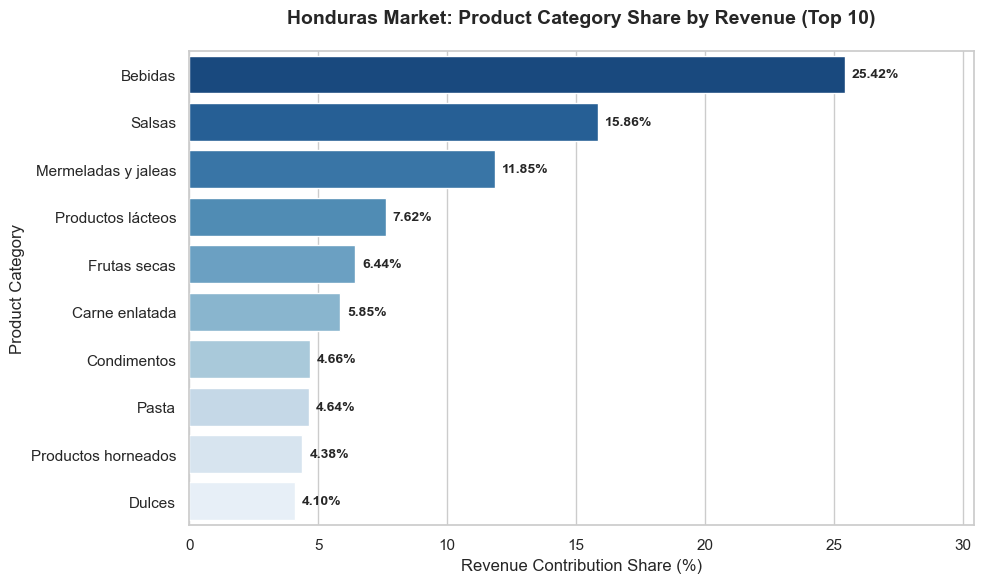

In [76]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plotting the top 10 categories to avoid cluttering the chart
top_categories = category_revenue.head(10)

ax = sns.barplot(
    data=top_categories, 
    x='Contribution_Share_%', 
    y='Categoría', 
    palette="Blues_r"
)

# Adding data labels to each bar for precise business interpretation
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=5, fontsize=10, fontweight='bold')

plt.title('Honduras Market: Product Category Share by Revenue (Top 10)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Revenue Contribution Share (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.xlim(0, top_categories['Contribution_Share_%'].max() + 5) # Leave room for labels
plt.tight_layout()

REGIONAL SALES PERFORMANCE ANALYSIS: CORTÉS
[INSIGHT] Top performing salesperson in Cortés: Nancy Gil de la Peña
[INSIGHT] Total revenue generated by leader: L. 943,632.90

--- Salesperson Rankings in Cortés ---
            Vendedor Total_Revenue Total_Units
Nancy Gil de la Peña L. 943,632.90       2,546
         José Castro L. 515,759.86       1,763
      Mayra Aguilar   L. 18,081.00         180
------------------------------------------------------------


C:\Users\hecto\AppData\Local\Temp\ipykernel_40244\495312381.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


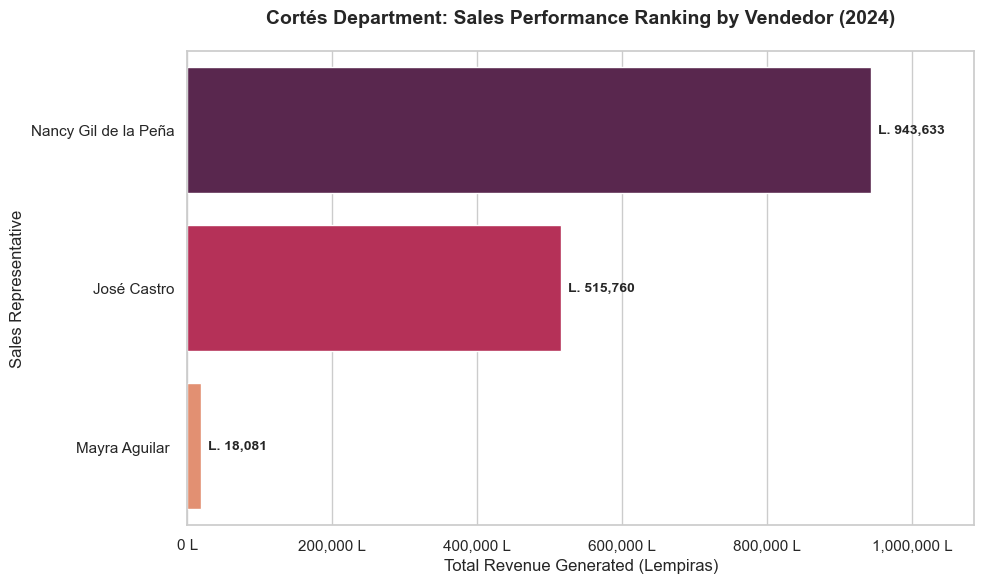

In [78]:
print("=" * 60)
print("REGIONAL SALES PERFORMANCE ANALYSIS: CORTÉS")
print("=" * 60)

# ----------------------------------------------------------------------
# 1. Filtering and Aggregating Data for Cortés Department
# ----------------------------------------------------------------------
# Filter rows where the Department is exactly 'Cortés'
cortes_df = df[df['Departamento'] == 'Cortés'].copy()

# Group by 'Vendedor' and calculate total revenue and total units sold
vendedor_perf = cortes_df.groupby('Vendedor').agg(
    Total_Revenue=('Ingresos', 'sum'),
    Total_Units=('Cantidad', 'sum')
).reset_index()

# Sort salespeople from highest to lowest revenue
vendedor_perf = vendedor_perf.sort_values(by='Total_Revenue', ascending=False)

# Identify the top-performing salesperson in Cortés
top_salesperson = vendedor_perf.iloc[0]['Vendedor']
top_revenue = vendedor_perf.iloc[0]['Total_Revenue']

print(f"[INSIGHT] Top performing salesperson in Cortés: {top_salesperson}")
print(f"[INSIGHT] Total revenue generated by leader: L. {top_revenue:,.2f}\n")

print("--- Salesperson Rankings in Cortés ---")
print(vendedor_perf.to_string(index=False, formatters={'Total_Revenue': 'L. {:,.2f}'.format, 'Total_Units': '{:,.0f}'.format}))
print("-" * 60)

# ----------------------------------------------------------------------
# 2. Data Visualization: Sales Rankings Chart
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a horizontal bar chart
ax = sns.barplot(
    data=vendedor_perf,
    x='Total_Revenue',
    y='Vendedor',
    palette="rocket"
)

# Customize axis and formatting to display revenue in Millions/Thousands cleanly
ax.xaxis.set_major_formatter('{x:,.0f} L')

# Append data value labels inside/at the edge of each bar for transparency
for container in ax.containers:
    ax.bar_label(container, fmt='L. {:,.0f}', padding=5, fontsize=10, fontweight='bold')

plt.title('Cortés Department: Sales Performance Ranking by Vendedor (2024)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Total Revenue Generated (Lempiras)', fontsize=12)
plt.ylabel('Sales Representative', fontsize=12)

# Dynamic x-axis margin optimization to prevent label clipping
plt.xlim(0, vendedor_perf['Total_Revenue'].max() * 1.15)
plt.tight_layout()

REGIONAL COMPARATIVE ANALYSIS: COPÁN VS. CORTÉS IN BEVERAGES
[INFO] Total Beverage records found for Copán & Cortés: 54

--- Beverage Performance Summary Table ---
Departamento Total_Revenue Total_Units_Sold Average_Ticket  Transaction_Count
       Copán L. 582,148.00            1,033   L. 30,639.37                 19
      Cortés L. 680,091.86            1,855   L. 19,431.20                 35
------------------------------------------------------------


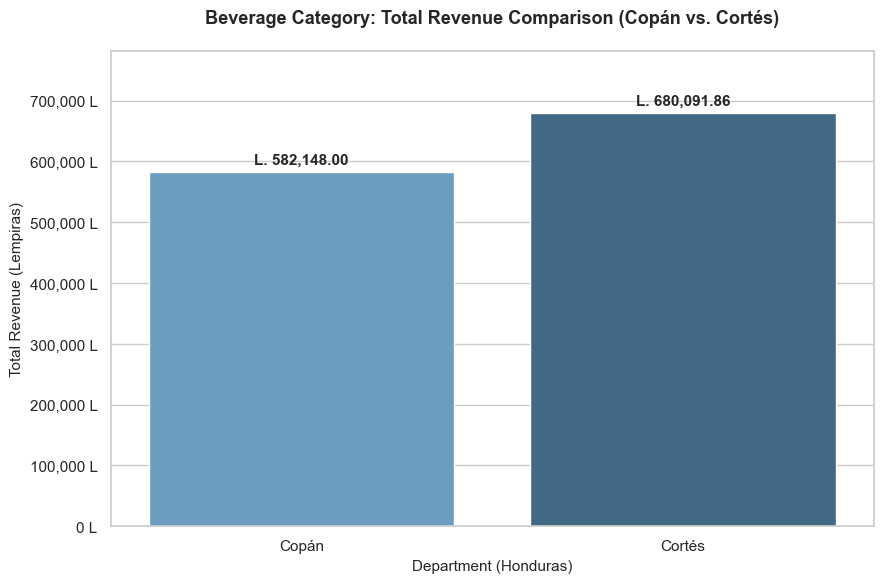

In [81]:
print("=" * 60)
print("REGIONAL COMPARATIVE ANALYSIS: COPÁN VS. CORTÉS IN BEVERAGES")
print("=" * 60)

# ----------------------------------------------------------------------
# 1. Filtering and Cleaning Target Data
# ----------------------------------------------------------------------
# Standardize string formatting to ensure perfect matching
df['Categoría'] = df['Categoría'].str.strip()
df['Departamento'] = df['Departamento'].str.strip()

# Apply filters: Category must be 'Bebidas' and Department must be Copán or Cortés
category_mask = df['Categoría'] == 'Bebidas'
department_mask = df['Departamento'].isin(['Copán', 'Cortés'])

comparison_df = df[category_mask & department_mask].copy()

print(f"[INFO] Total Beverage records found for Copán & Cortés: {comparison_df.shape[0]}")

# ----------------------------------------------------------------------
# 2. Data Aggregation and Metrics Computing
# ----------------------------------------------------------------------
if not comparison_df.empty:
    # Group by Department to calculate key commercial KPIs
    regional_metrics = comparison_df.groupby('Departamento').agg(
        Total_Revenue=('Ingresos', 'sum'),
        Total_Units_Sold=('Cantidad', 'sum'),
        Average_Ticket=('Ingresos', 'mean'),
        Transaction_Count=('Folio', 'nunique')
    ).reset_index()

    print("\n--- Beverage Performance Summary Table ---")
    print(regional_metrics.to_string(index=False, formatters={
        'Total_Revenue': 'L. {:,.2f}'.format, 
        'Total_Units_Sold': '{:,.0f}'.format,
        'Average_Ticket': 'L. {:,.2f}'.format
    }))
    print("-" * 60)

    # ----------------------------------------------------------------------
    # 3. Data Visualization: Comparative Bar Chart
    # ----------------------------------------------------------------------
    plt.figure(figsize=(9, 6))
    sns.set_theme(style="whitegrid")

    # Create a professional bar chart comparing Revenue
    ax = sns.barplot(
        data=regional_metrics,
        x='Departamento',
        y='Total_Revenue',
        palette="Blues_d",
        hue='Departamento',
        legend=False
    )

    # Format the Y-axis numbers cleanly as Lempiras currency
    ax.yaxis.set_major_formatter('{x:,.0f} L')

    # Add precision data labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='L. {:,.2f}', padding=4, fontsize=11, fontweight='bold')

    plt.title('Beverage Category: Total Revenue Comparison (Copán vs. Cortés)', fontsize=13, pad=20, fontweight='bold')
    plt.xlabel('Department (Honduras)', fontsize=11)
    plt.ylabel('Total Revenue (Lempiras)', fontsize=11)
    
    # Expand y-axis overhead limit slightly to prevent label clipping
    plt.ylim(0, regional_metrics['Total_Revenue'].max() * 1.15)
    plt.tight_layout()

# Random Forest Regressor


DEVELOPING MACHINE LEARNING MODEL: RANDOM FOREST REGRESSOR
[INFO] Dataset split successfully.
[INFO] Training samples: 292 | Testing samples: 74
[INFO] Total encoded features for training: 21
[INFO] Random Forest model training completed.

--- Model Performance Evaluation Metrics ---
Mean Absolute Error (MAE): L. 173.15
Root Mean Squared Error (RMSE): L. 387.70
R-squared Score (R2 Coefficient): 0.9561
----------------------------------------

--- Top 10 Most Influential Features on Shipping Fees ---
                              Feature Importance
                      Precio unitario     0.5958
                             Cantidad     0.3709
        Categoría_Mermeladas y jaleas     0.0256
                    Categoría_Bebidas     0.0011
Empresa fletera_Empresa de embarque C     0.0010
        Empresa fletera_Not Specified     0.0008
                         Region_Norte     0.0008
Empresa fletera_Empresa de embarque B     0.0007
          Categoría_Productos lácteos     0.0006
     

C:\Users\hecto\AppData\Local\Temp\ipykernel_40244\2449254948.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


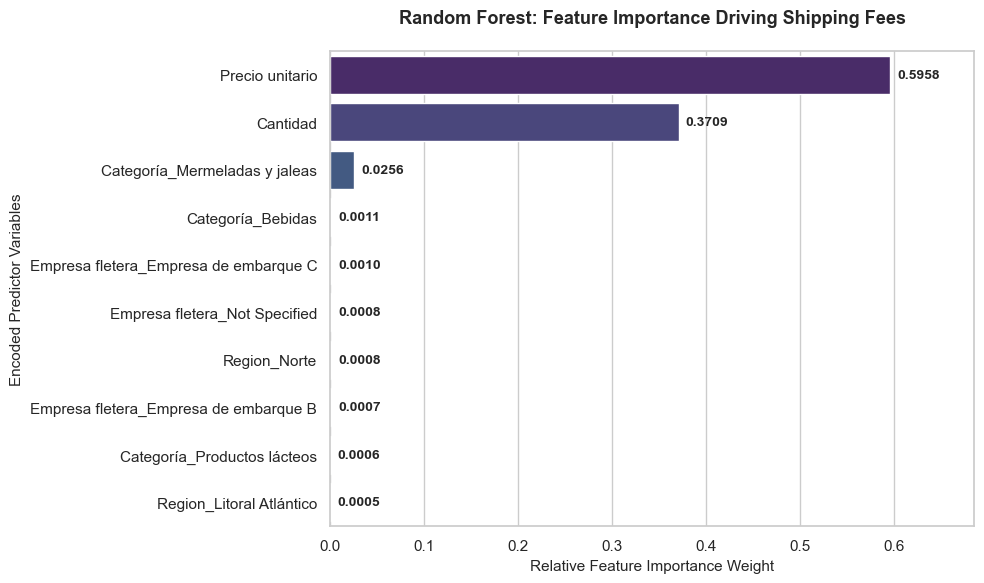

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("=" * 60)
print("DEVELOPING MACHINE LEARNING MODEL: RANDOM FOREST REGRESSOR")
print("=" * 60)

# ----------------------------------------------------------------------
# 1. Feature Selection & Preprocessing
# ----------------------------------------------------------------------
# Selecting predictors that influence logictics and freight costs
features = ['Region', 'Empresa fletera', 'Categoría', 'Cantidad', 'Precio unitario']
target = 'Tarifa de envío'

# Filter the dataframe to ensure no missing values interfere with training
ml_df = df[features + [target]].dropna().copy()

# Standardize string formatting to avoid categorical alignment errors
categorical_cols = ['Region', 'Empresa fletera', 'Categoría']
for col in categorical_cols:
    ml_df[col] = ml_df[col].astype(str).str.strip()

# Convert Categorical features into Numerical using One-Hot Encoding
ml_df_encoded = pd.get_dummies(ml_df, columns=categorical_cols, drop_first=True)

# ----------------------------------------------------------------------
# 2. Splitting Data into Training and Testing Sets
# ----------------------------------------------------------------------
X = ml_df_encoded.drop(columns=[target])
y = ml_df_encoded[target]

# 80% Train, 20% Test split for evaluation integrity
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"[INFO] Dataset split successfully.")
print(f"[INFO] Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")
print(f"[INFO] Total encoded features for training: {X_train.shape[1]}")

# ----------------------------------------------------------------------
# 3. Model Training: Random Forest
# ----------------------------------------------------------------------
# Instantiating the regressor with 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("[INFO] Random Forest model training completed.")

# ----------------------------------------------------------------------
# 4. Model Evaluation & Performance Metrics
# ----------------------------------------------------------------------
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): L. {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): L. {rmse:.2f}")
print(f"R-squared Score (R2 Coefficient): {r2:.4f}")
print("-" * 40)

# ----------------------------------------------------------------------
# 5. Extracting and Plotting Feature Importance
# ----------------------------------------------------------------------
# Extract the structural mathematical weights of each feature
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Filter for top 10 features to keep the documentation visualization clean
top_features = feature_importance_df.head(10)

print("\n--- Top 10 Most Influential Features on Shipping Fees ---")
print(top_features.to_string(index=False, formatters={'Importance': '{:.4f}'.format}))
print("-" * 60)

# ----------------------------------------------------------------------
# 6. Data Visualization: Feature Importance Bar Chart
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    palette="viridis"
)

# Append percentage data labels to the bars for visual transparency
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=10, fontweight='bold')

plt.title('Random Forest: Feature Importance Driving Shipping Fees', fontsize=13, pad=20, fontweight='bold')
plt.xlabel('Relative Feature Importance Weight', fontsize=11)
plt.ylabel('Encoded Predictor Variables', fontsize=11)
plt.xlim(0, top_features['Importance'].max() * 1.15)
plt.tight_layout()